<a href="https://colab.research.google.com/github/ddeekshitha0099-dotcom/calculating-family-expences/blob/main/FUTURE_ML_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📩 Customer Support Ticket Classification System (NLP Project)

# 🧠 Skills Demonstrated
Natural Language Processing (NLP)
Text preprocessing
TF-IDF feature extraction
Machine learning classification
Priority logic automation

# About Dataset


The Customer Support Ticket Dataset is a dataset that includes customer support tickets for various tech products. It consists of customer inquiries related to hardware issues, software bugs, network problems, account access, data loss, and other support topics. The dataset provides information about the customer, the product purchased, the ticket type, the ticket channel, the ticket status, and other relevant details.

The dataset can be used for various analysis and modelling tasks in the customer service domain.

# Introduction


Customer support is an essential part of any business as it helps resolve customer issues and improve satisfaction. Organizations receive many support tickets daily containing various problems and inquiries. Manually reviewing and categorizing these tickets can be time-consuming and inefficient. Using Natural Language Processing (NLP) and Machine Learning techniques, support tickets can be automatically classified based on their content. This project develops a system that classifies tickets and assigns priority levels to improve response time and service efficiency.



# Problem Statement


In many organizations, customer support teams receive a high volume of support tickets every day. These tickets may include technical problems, payment issues, service complaints, or general inquiries. Manually reviewing and categorizing each ticket is time-consuming and may lead to delays in responding to urgent issues. Identifying the priority level of each ticket is also challenging when done manually. An automated system can help classify tickets based on their content. It can also assign priority levels such as high, medium, or low. This improves response time and overall customer service efficiency.

# Project description



This project focuses on building an automated system for classifying customer support tickets and assigning priority levels using Natural Language Processing and Machine Learning techniques.

The dataset used in this project contains customer support ticket information, including ticket descriptions and categories. The ticket descriptions are first cleaned using text preprocessing techniques such as removing punctuation, converting text to lowercase, and eliminating stopwords.

After preprocessing, the text data is converted into numerical form using TF-IDF vectorization, which helps the machine learning model understand the importance of words in the tickets. A classification model (Naive Bayes) is then trained to predict the category of new support tickets.

Additionally, a priority tagging system is implemented based on specific keywords present in the ticket text. For example, tickets containing words like error, failed, or urgent are marked as High Priority, while less critical requests are categorized as Medium or Low Priority.

The system is evaluated using performance metrics such as accuracy, precision, recall, and F1-score to measure the effectiveness of the classification model.

By automating ticket classification and priority assignment, the system helps support teams quickly identify critical issues and respond more efficiently, ultimately improving customer satisfaction and service management.

## step 1: Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Description

* Ticket ID: A unique identifier for each ticket.

* Customer Name: The name of the customer who raised the ticket.

* Customer Email: The email address of the customer (Domain name - @example.com is intentional for user data privacy concern).

* Customer Age: The age of the customer.

* Customer Gender: The gender of the customer.

* Product Purchased: The tech product purchased by the customer.

* Date of Purchase: The date when the product was purchased.

* Ticket Type: The type of ticket (e.g., technical issue, billing inquiry, product inquiry).

* Ticket Subject: The subject/topic of the ticket.

* Ticket Description: The description of the customer's issue or inquiry.

* Ticket Status: The status of the ticket (e.g., open, closed, pending customer response).

* Resolution: The resolution or solution provided for closed tickets.

* Ticket Priority: The priority level assigned to the ticket (e.g., low, medium, high, critical).

* Ticket Channel: The channel
through which the ticket was raised (e.g., email, phone, chat, social media).

* First Response Time: The time taken to provide the first response to the customer.

* Time to Resolution: The time taken to resolve the ticket.

* Customer Satisfaction Rating: The customer's satisfaction rating for closed tickets (on a scale of 1 to 5).

## step 2: Load Dataset

In [4]:
df = pd.read_csv("/content/customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [6]:
df.shape

(8469, 17)

In [7]:
df.size

143973

## step 3: Select Important Columns

In [11]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [13]:
df = df[['Ticket Description','Ticket Type']]
df.head()

,Ticket Description,Ticket Type
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


## step 4:Text Cleaning

In [14]:
df = df[['Ticket Description','Ticket Type']]

df.rename(columns={'Ticket Type':'Category'}, inplace=True)

df.head()

,Ticket Description,Category
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


In [17]:
X = df['Ticket Description']
y = df['Category']

In [21]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['Ticket Description'].apply(clean_text)

df.head()

,Ticket Description,Category,clean_text
0,I'm having an issue with the {product_purchase...,Technical issue,issue product purchased please assist billing ...
1,I'm having an issue with the {product_purchase...,Technical issue,issue product purchased please assist need cha...
2,I'm facing a problem with my {product_purchase...,Technical issue,facing problem product purchased product purch...
3,I'm having an issue with the {product_purchase...,Billing inquiry,issue product purchased please assist problem ...
4,I'm having an issue with the {product_purchase...,Billing inquiry,issue product purchased please assist note sel...


## step 5: Test Tokenization

In [22]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_text'])

In [24]:
y = df['Category']

## step 6: Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## step 7: Train NLP Classification Model

In [26]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

## step 8: Predict Ticket Categories

In [27]:
predictions = model.predict(X_test)

## step 9: Model Performance Evaluation

In [28]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print(classification_report(y_test, predictions))

Accuracy: 0.18654073199527746
                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.05      0.08       357
Cancellation request       0.18      0.17      0.17       327
     Product inquiry       0.14      0.11      0.12       316
      Refund request       0.19      0.29      0.23       345
     Technical issue       0.21      0.32      0.25       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



## step 10: Priority Tagging Logic

In [29]:
def assign_priority(text):

    text = text.lower()

    if "error" in text or "failed" in text or "urgent" in text:
        return "High"

    elif "delay" in text or "issue" in text:
        return "Medium"

    else:
        return "Low"

In [31]:
df['Priority'] = df['Ticket Description'].apply(assign_priority)

df.head()

,Ticket Description,Category,clean_text,Priority
0,I'm having an issue with the {product_purchase...,Technical issue,issue product purchased please assist billing ...,Medium
1,I'm having an issue with the {product_purchase...,Technical issue,issue product purchased please assist need cha...,Medium
2,I'm facing a problem with my {product_purchase...,Technical issue,facing problem product purchased product purch...,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,issue product purchased please assist problem ...,Medium
4,I'm having an issue with the {product_purchase...,Billing inquiry,issue product purchased please assist note sel...,Medium


## step 11: Test the System

In [32]:
new_ticket = ["Payment failed while processing order"]

clean_ticket = clean_text(new_ticket[0])

vector = vectorizer.transform([clean_ticket])

prediction = model.predict(vector)

print("Predicted Category:", prediction[0])

print("Priority:", assign_priority(new_ticket[0]))

Predicted Category: Product inquiry
Priority: High


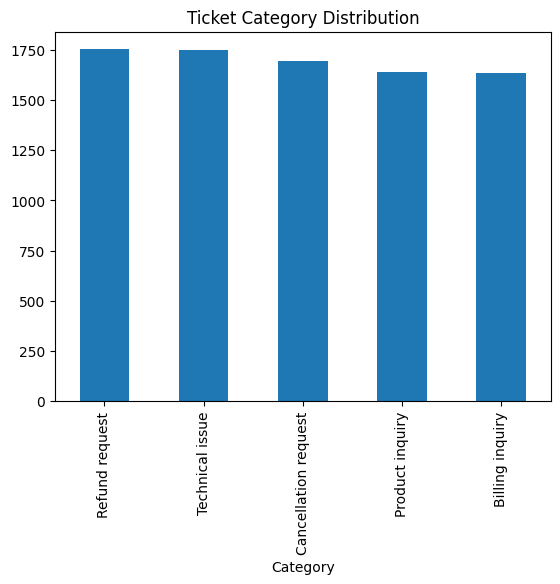

In [34]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')

plt.title("Ticket Category Distribution")

plt.show()

In [35]:
# Example new ticket
new_ticket = ["My payment failed and I cannot complete the purchase"]

# Clean the ticket text
clean_ticket = clean_text(new_ticket[0])

# Convert text into TF-IDF features
vector = vectorizer.transform([clean_ticket])

# Predict ticket category
predicted_category = model.predict(vector)

print("Predicted Ticket Category:", predicted_category[0])

Predicted Ticket Category: Refund request


In [36]:
# Function to assign priority

def assign_priority(text):

    text = text.lower()

    if "error" in text or "failed" in text or "urgent" in text:
        return "High"

    elif "delay" in text or "issue" in text:
        return "Medium"

    else:
        return "Low"

In [37]:
priority = assign_priority(new_ticket[0])

print("Ticket Description:", new_ticket[0])
print("Predicted Category:", predicted_category[0])
print("Priority Level:", priority)

Ticket Description: My payment failed and I cannot complete the purchase
Predicted Category: Refund request
Priority Level: High


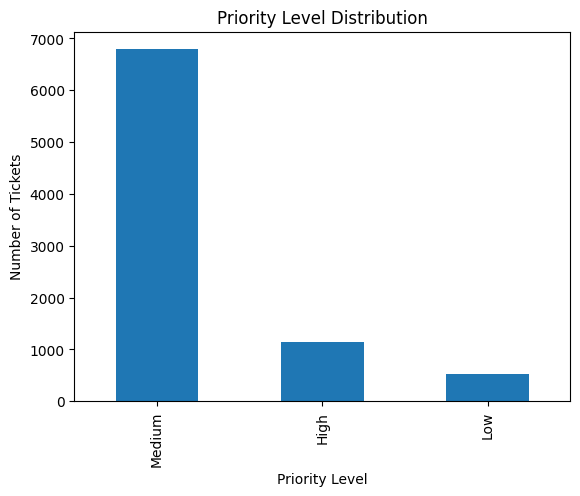

In [41]:
df['Priority'].value_counts().plot(kind='bar')

plt.title("Priority Level Distribution")
plt.xlabel("Priority Level")
plt.ylabel("Number of Tickets")

plt.show()

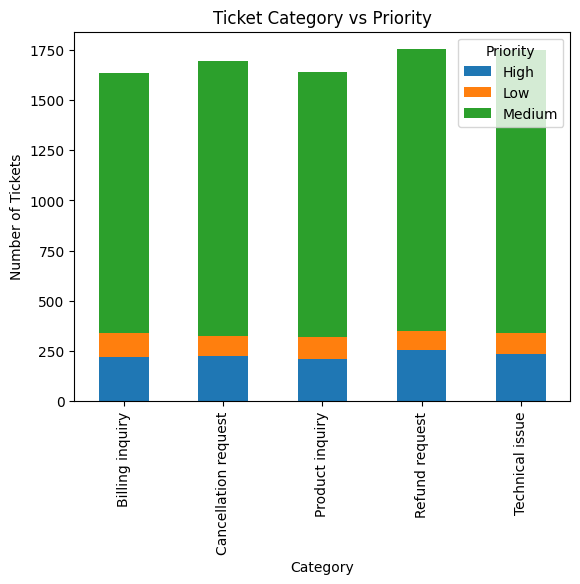

In [43]:
import pandas as pd

pd.crosstab(df['Category'], df['Priority']).plot(kind='bar', stacked=True)

plt.title("Ticket Category vs Priority")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")

plt.show()

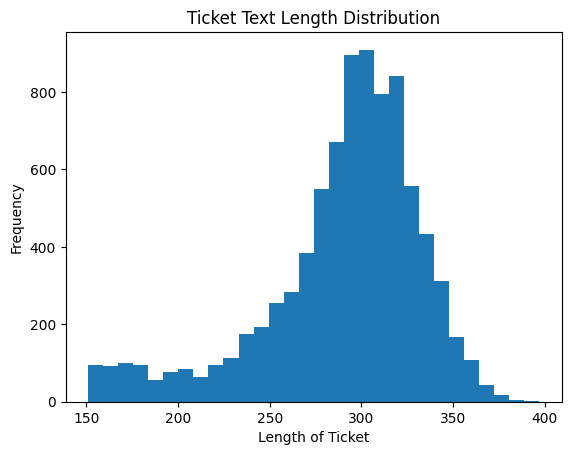

In [45]:
df['text_length'] = df['Ticket Description'].apply(len)

plt.hist(df['text_length'], bins=30)

plt.title("Ticket Text Length Distribution")
plt.xlabel("Length of Ticket")
plt.ylabel("Frequency")

plt.show()

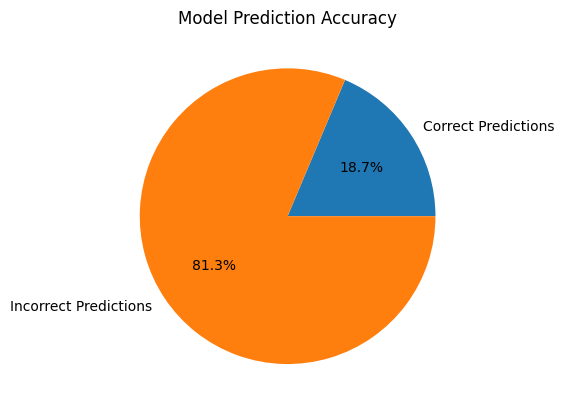

In [46]:
labels = ['Correct Predictions','Incorrect Predictions']

values = [accuracy*100, 100-(accuracy*100)]

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Model Prediction Accuracy")

plt.show()

# Conclusion


In this project, a Customer Support Ticket Classification System was developed using Natural Language Processing (NLP) and Machine Learning techniques. The system processes customer support ticket descriptions, cleans the text data, and converts it into numerical form using TF-IDF vectorization. A machine learning classification model was then trained to automatically categorize tickets based on their content.

Additionally, a priority tagging mechanism was implemented to assign priority levels such as High, Medium, and Low based on the urgency of the ticket description. This helps support teams quickly identify critical issues and respond more efficiently.

The model was evaluated using performance metrics such as accuracy, precision, recall, and F1-score, which helped measure the effectiveness of the classification system. The results show that automated ticket classification can significantly reduce manual effort and improve response time.

Overall, this system demonstrates how Natural Language Processing and Machine Learning can be used to automate customer support processes, helping organizations manage support tickets more efficiently and improve customer satisfaction.

Future improvements could include using advanced models such as Logistic Regression, Support Vector Machines, or Deep Learning models and integrating the system with real-time customer support platforms.